In [1]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random

import tensorflow as tf

# feste Seeds damit Zufallsprozesse das Ergebnis nicht beeinflusst
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only those gestures
CONDITIONS = ['like', 'stop']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3

PATH = '../gesture_dataset_sample'

2026-06-22 12:15:25.982569: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## helper function to load and parse annotations

In [2]:
annotations = dict()

for condition in CONDITIONS:
    with open(f'{PATH}/_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

In [3]:
# pretty-print first element
#000484ab-5fd0-49b8-9253-23a22b71d7b1
print(json.dumps(annotations['like']['0014182f-d756-42b3-896c-c52de76926bb'], indent=2))

{
  "bboxes": [
    [
      0.38056273,
      0.35650891,
      0.17322347,
      0.10461114
    ]
  ],
  "labels": [
    "like"
  ],
  "landmarks": [
    [
      [
        0.5497169170918876,
        0.4276043615779976
      ],
      [
        0.5218336293004483,
        0.40536586667786917
      ],
      [
        0.48288133220125257,
        0.3930262243722419
      ],
      [
        0.4501841862302019,
        0.37981099195030416
      ],
      [
        0.44251365410099686,
        0.36620499322043343
      ],
      [
        0.43138297470865106,
        0.406093902776592
      ],
      [
        0.4072660997339628,
        0.4073950234480344
      ],
      [
        0.42588200316326846,
        0.40612291879594015
      ],
      [
        0.4441470003072778,
        0.4049221293588555
      ],
      [
        0.4314493576491367,
        0.4212979654419442
      ],
      [
        0.42096276272263283,
        0.4180224457320293
      ],
      [
        0.43966095717106257,
      

## helper function to pre-process images (color channel conversion and resizing)

In [4]:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## load images and annotations

In [5]:
images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(f'{PATH}/{condition}')):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'{PATH}/{condition}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

  0%|          | 0/250 [00:00<?, ?it/s]

100%|██████████| 250/250 [00:12<00:00, 20.57it/s]


## let's have a look at one of the images

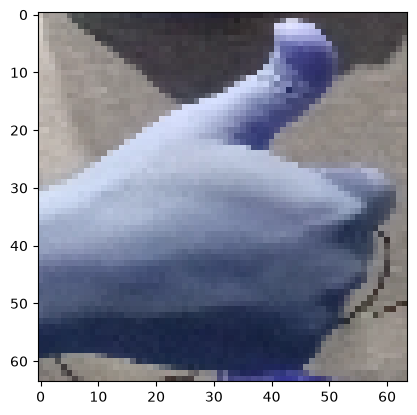

In [6]:
plt.imshow(random.sample(images, 1)[0])
#plt.imshow(random.sample(images, 1)[0], cmap='gray')

## split data set into train and test

x is for the actual data, y is for the label (this is convention)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

512
128
512
128


## transform data sets into a format compatible with our neural network

image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]

furthermore, scale all values to a range of 0 to 1

training data has to be converted to a categorial vector ("one hot"):

[3] --> [0, 0, 0, 1, 0, ..., 0]

In [8]:
# Convert to float
X_train = np.array(X_train).astype('float32')
# Normalization [0,1]
X_train = X_train / 255.

X_test = np.array(X_test).astype('float32')
X_test = X_test / 255.


# Convert interger class labels in to one hot vector
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

# rename for demonstration purposes
train_label = y_train_one_hot
test_label = y_test_one_hot

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

(512, 64, 64, 3) (128, 64, 64, 3) (512, 3) (128, 3)


In [104]:
# variables for hyperparameters
batch_size = 8 
epochs = 50 
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'leaky_relu'
layer_count = 2
num_neurons = 10

# define model structure
# with keras, we can use a model's add() function to add layers to the network one by one
model = Sequential()

# data augmentation (this can also be done beforehand - but don't augment the test dataset!)
model.add(RandomFlip('horizontal'))
model.add(RandomContrast(0.1))
#model.add(RandomBrightness(0.1))
#model.add(RandomRotation(0.2))

# first, we add some convolution layers followed by max pooling
model.add(Conv2D(64, kernel_size=(9, 9), activation=activation_conv, input_shape=(SIZE[0], SIZE[1], COLOR_CHANNELS), padding='same'))
model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

model.add(Conv2D(32, (5, 5), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

model.add(Conv2D(32, (3, 3), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

# Randomly disables 20% of neurons during each training step
model.add(Dropout(0.2))

# after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
model.add(Flatten())

# add some fully connected layers ("Dense")
for i in range(layer_count - 1):
    model.add(Dense(num_neurons, activation=activation))

model.add(Dense(num_neurons, activation=activation))

# for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
model.add(Dense(num_classes, activation='softmax'))

# specify loss function, optimizer and evaluation metrics
# for classification, categorial crossentropy is used as a loss function
# use the adam optimizer unless you have a good reason not to
model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

# define callback functions that react to the model's behavior during training
# in this example, we reduce the learning rate once we get stuck and early stopping
# to cancel the training if there are no improvements for a certain amount of epochs

# If validation loss stops improving for 2 epochs, multiply  the learning rate by 0.2 (slow down/fine tune)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
# if validation loss doesn't improve for 3 epchs, stop training entierly
stop_early = EarlyStopping(monitor='val_loss', patience=3)

print(num_neurons)

10


/Users/anjafranke/InteractionTechniques/Assignment5/assignment-05-cnn-Anja0901/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Hyperparameter:
Anzahl der Neuronen in den Fully Connected Layers. 

Hierfür werden 5, 16, 64, 256 und 600 Neuronen betrachtet. Alle übrigen Hyperparameter bleiben unverändert. 
Es wird ein fester Random Seed verwendet, damit das Ergebnis weniger von Zufallsprozessen abhängt.

Es wird angenommen, dass eine größere Anzahl von Neuronen zu besseren Klassifikationen führt (höhere prediction  accuracy), da das Modell komplexer wird. Gleichzeitig wird erwartet, dass mehr Neuronen mehr Rechenleistung benötigen und damit die Vorhersagen länger dauern (höhere inference time for predictions).

Ergebnis:

Bei 5 Neuronen:

- Inferenz Time: 0.004895 Sekunden durchschnittlich pro Bild
- Accuracy: 0.3125

Bei 16 Neuronen:

- Inferenz Time: 0.0051535 Sekunden durchschnittlich pro Bild
- Accuracy: 0.9296875

Bei 64 Neuronen:

- Inferenz Time: 0.0081238 Sekunden durchschnittlich pro Bild
- Accuracy: 0.8984375

Bei 256 Neuronen:

- Inferenz Time: 0.0060154 Sekunden durchschnittlich pro Bild
- Accuracy: 0.890625

Bei 600 Neuronen:

- Inferenz Time: 0.008157 Sekunden durchschnittlich pro Bild
- Accuracy: 0.8984375

Die Ergebnisse zeigen, dass eine sehr kleine Anzahl von Neuronen (z.B. 5 Neuronen) zu einer sehr schlechteren Klassifikationsleistung führt. Dies lässt darauf schließen, dass sehr wenige Neuronen nicht ausreichen, um die für die Klassifikation relevanten Merkmale angemessen zu repräsentieren.

Die höchste Accuracy wurde mit 16 Neuronen erreicht. Eine weitere Erhöhung auf 64, 256 oder 600 Neuronen führte zu keiner Verbesserung der Accuracy, stattdessen sogar zu einer leichten Verschlechterung. Dies deutet darauf hin, dass die zusätzlichen Neuronen keinen weiteren Nutzen hinsichtilich der Generalisierung auf den Testdaten bietet. Stattdessen könnte eine höhere Anzahl von Neuronen zu einer stärkeren Anpassung an die Trainingsdaten führen (Overfitting), was erklären würde, warum die Test Accuracy sich wieder leicht verschlechtert hat.

Bei der Messung der Inference Time zeigte sich tendenziell ein leichter Anstieg für mehr Neuronen. Die gemessenen Zeiten wiesen jedoch relativ starke Schwankungen auf, sodass dieser Effekt nur eingeschränkt bewertet werden kann. Die Schwankungen können durch Systemeinflüsse oder unterschiedlichen CPU Auslastungen verursacht werden.


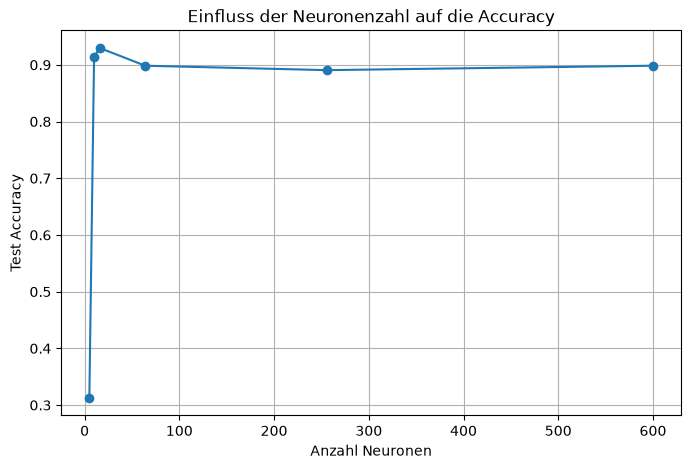

In [114]:
neurons = [5, 10, 16, 64, 256, 600]

#Ergebnisse
accuracies = [
    0.3125,
    0.9140625,
    0.9296875,
    0.8984375,
    0.890625,
    0.8984375
]

times = [
    0.004895177679600238,
    0.006567384726395176,
    0.005153500414053269,
    0.008123811093810218,
    0.006015449367168912,
    0.00815678440631018
]

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(neurons, accuracies, marker='o')
plt.xlabel("Anzahl Neuronen")
plt.ylabel("Test Accuracy")
plt.title("Einfluss der Neuronenzahl auf die Accuracy")
plt.grid()
plt.show()

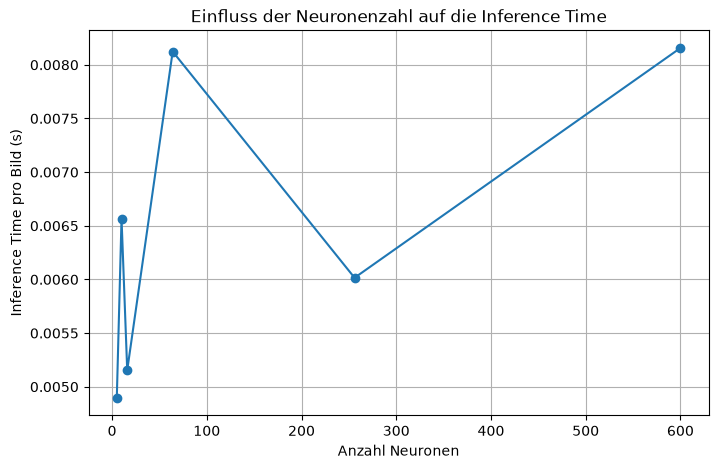

In [115]:
#Inteference Time Plot
plt.figure(figsize=(8,5))
plt.plot(neurons, times, marker='o')
plt.xlabel("Anzahl Neuronen")
plt.ylabel("Inference Time pro Bild (s)")
plt.title("Einfluss der Neuronenzahl auf die Inference Time")
plt.grid()
plt.show()

## now, we can train the model using the fit() function
## this will take a while

In [105]:
history = model.fit(
    X_train,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, test_label),
    callbacks=[reduce_lr, stop_early]
)

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step - accuracy: 0.4238 - loss: 1.0607 - val_accuracy: 0.3125 - val_loss: 1.0911 - learning_rate: 0.0010
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 195ms/step - accuracy: 0.4082 - loss: 1.0455 - val_accuracy: 0.3125 - val_loss: 1.0615 - learning_rate: 0.0010
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 161ms/step - accuracy: 0.4199 - loss: 1.0302 - val_accuracy: 0.3125 - val_loss: 1.1715 - learning_rate: 0.0010
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 214ms/step - accuracy: 0.5000 - loss: 1.0325 - val_accuracy: 0.3281 - val_loss: 1.0965 - learning_rate: 0.0010
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 208ms/step - accuracy: 0.5078 - loss: 0.9685 - val_accuracy: 0.4922 - val_loss: 0.9656 - learning_rate: 2.0000e-04
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 193ms/step - accuracy: 0.5566 - loss: 0.9186 - val_accuracy: 0.4766 - val_loss: 0.9512 - learning_rate: 2.0000e-04
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 181ms/step - accuracy: 0.5801 - 

In [106]:
loss, accuracy = model.evaluate(X_test, test_label)

print("Test Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.9141 - loss: 0.2925
Test Accuracy: 0.9140625


In [107]:
# let's have a look at our model
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_6 (RandomFlip)      │ (8, 64, 64, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_6               │ (8, 64, 64, 3)         │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (8, 64, 64, 64)        │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (8, 16, 16, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (8, 16, 16, 32)        │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (8, 6, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (8, 6, 6, 32)          │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (8, 3, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (8, 3, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (8, 288)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (8, 10)                │         2,890 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (8, 10)                │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (8, 3)                 │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 237,389 (927.30 KB)

 Trainable params: 79,129 (309.10 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 158,260 (618.21 KB)

## Plot accuracy and loss of the training process

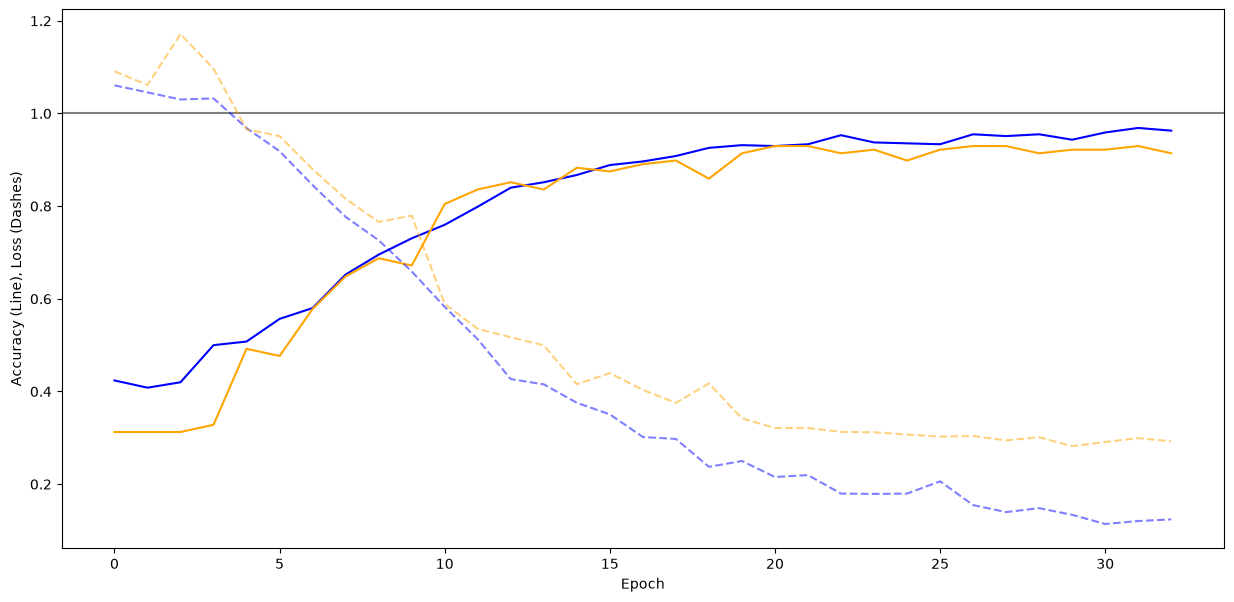

In [108]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (Line), Loss (Dashes)')

ax.axhline(1, color='gray')

plt.plot(accuracy, color='blue')
plt.plot(val_accuracy, color='orange')
plt.plot(loss, '--', color='blue', alpha=0.5)
plt.plot(val_loss, '--', color='orange', alpha=0.5)

## saving the model

the function will create a directory for your model and save structure and weights in there

sometimes you will see the .h5 format being used - even though this is a bit faster and needs less space, it comes with its limitations and isn't used that much any more

In [109]:
model.save('gesture_recognition.keras')

# and this is how you load the model
# model = keras.models.load_model("gesture_recognition.keras")

## visualize classification results with a confusion matrix

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step
Inference Time (gesamt): 0.8406252449785825 Sekunden
Inference Time pro Bild: 0.006567384726395176 Sekunden
before [[2.48586037e-03 9.96613204e-01 9.00781888e-04]
 [9.99983609e-01 6.13370867e-06 1.03079155e-05]
 [9.99994934e-01 4.15373916e-06 7.88833290e-07]
 [5.26044006e-03 9.94455397e-01 2.84178794e-04]
 [1.78727380e-03 9.98091340e-01 1.21392477e-04]
 [9.50982571e-01 1.20003838e-02 3.70169953e-02]
 [8.73320103e-01 2.90893810e-03 1.23770945e-01]
 [9.19796526e-01 7.96548501e-02 5.48613898e-04]
 [9.87771690e-01 7.30739534e-03 4.92080906e-03]
 [5.33302315e-02 9.23495114e-01 2.31746770e-02]
 [3.15434486e-02 7.57701099e-02 8.92686427e-01]
 [9.99997079e-01 2.60967681e-06 1.83653881e-07]
 [1.06929197e-04 9.99872446e-01 2.06004206e-05]
 [1.52559439e-03 9.84544218e-01 1.39300292e-02]
 [8.52590561e-01 1.43263534e-01 4.14581737e-03]
 [6.97642099e-03 6.74941903e-03 9.86274183e-01]
 [1.94913745e-02 8.76205135e-03 9.71746504e-01]
 [2.67426204e-03 8.26104078e-0

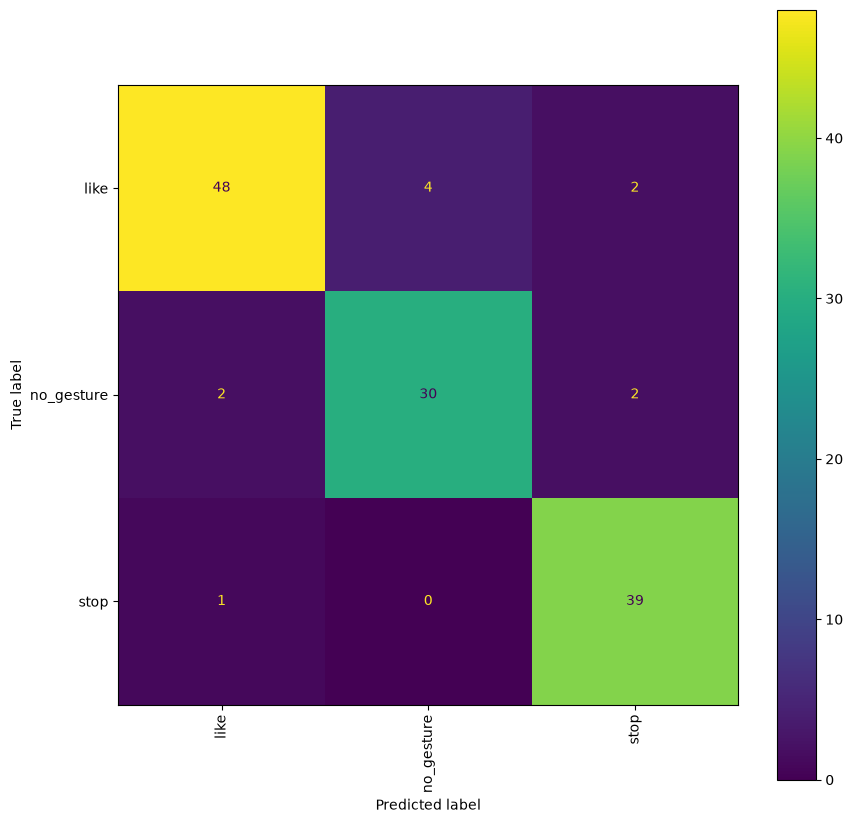

In [113]:
import time

start = time.perf_counter()

# let the model make predictions for our test data
y_predictions = model.predict(X_test)

end = time.perf_counter()

inference_time = end - start

print("Inference Time (gesamt):", inference_time, "Sekunden")
print("Inference Time pro Bild:", inference_time / len(X_test), "Sekunden")

# we get a 2D numpy array with probabilities for each category
print('before', y_predictions)

# to build a confusion matrix, we have to convert it to classifications
# this can be done by using the argmax() function to set the probability to 1 and the rest to 0
y_predictions = np.argmax(y_predictions, axis=1)

print('probabilities', y_predictions)

# create and plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_predictions)

fig = plt.figure(figsize=(10, 10))

ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())

plt.xticks(rotation=90, ha='center')
pass

## let's test our model in action

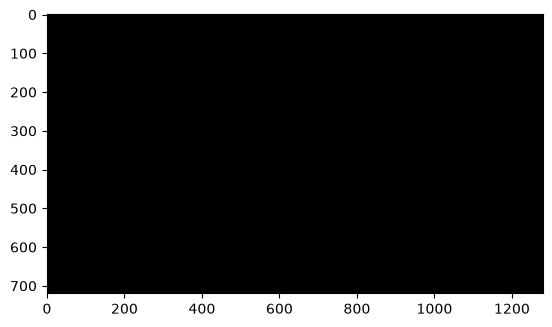

In [122]:
# for mac users: you may have to add time.sleep(1) as the mac camera has a short fade in time. Furthermore possibly it will select your IPhone camera: you can deactivate this
cap = cv2.VideoCapture(0)
ret, frame = cap.read()
if COLOR_CHANNELS == 1:
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
cap.release()
plt.imshow(frame)

## manual cropping for demonstration purposes - you can do better!

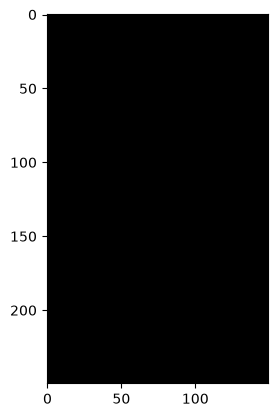

In [123]:
cropped = frame[150:400, 300:450]
plt.imshow(cropped)

(64, 64, 3)

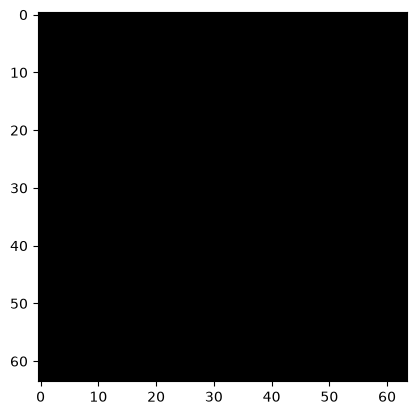

In [124]:
resized = cv2.resize(cropped, SIZE)#[20:350, 200:420], SIZE)
plt.imshow(resized)
resized.shape

In [125]:
reshaped = resized.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
reshaped.shape
prediction = model.predict(reshaped)

print(label_names[np.argmax(prediction)], np.max(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step
no_gesture 0.47194293


(9, 9, 3, 64)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.54962254..0.49652755].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7698751..0.6917896].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.72010666..0.5385658].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.79485565..0.5789045].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8831415..0.7155596].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.38375735..0.32741275].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.

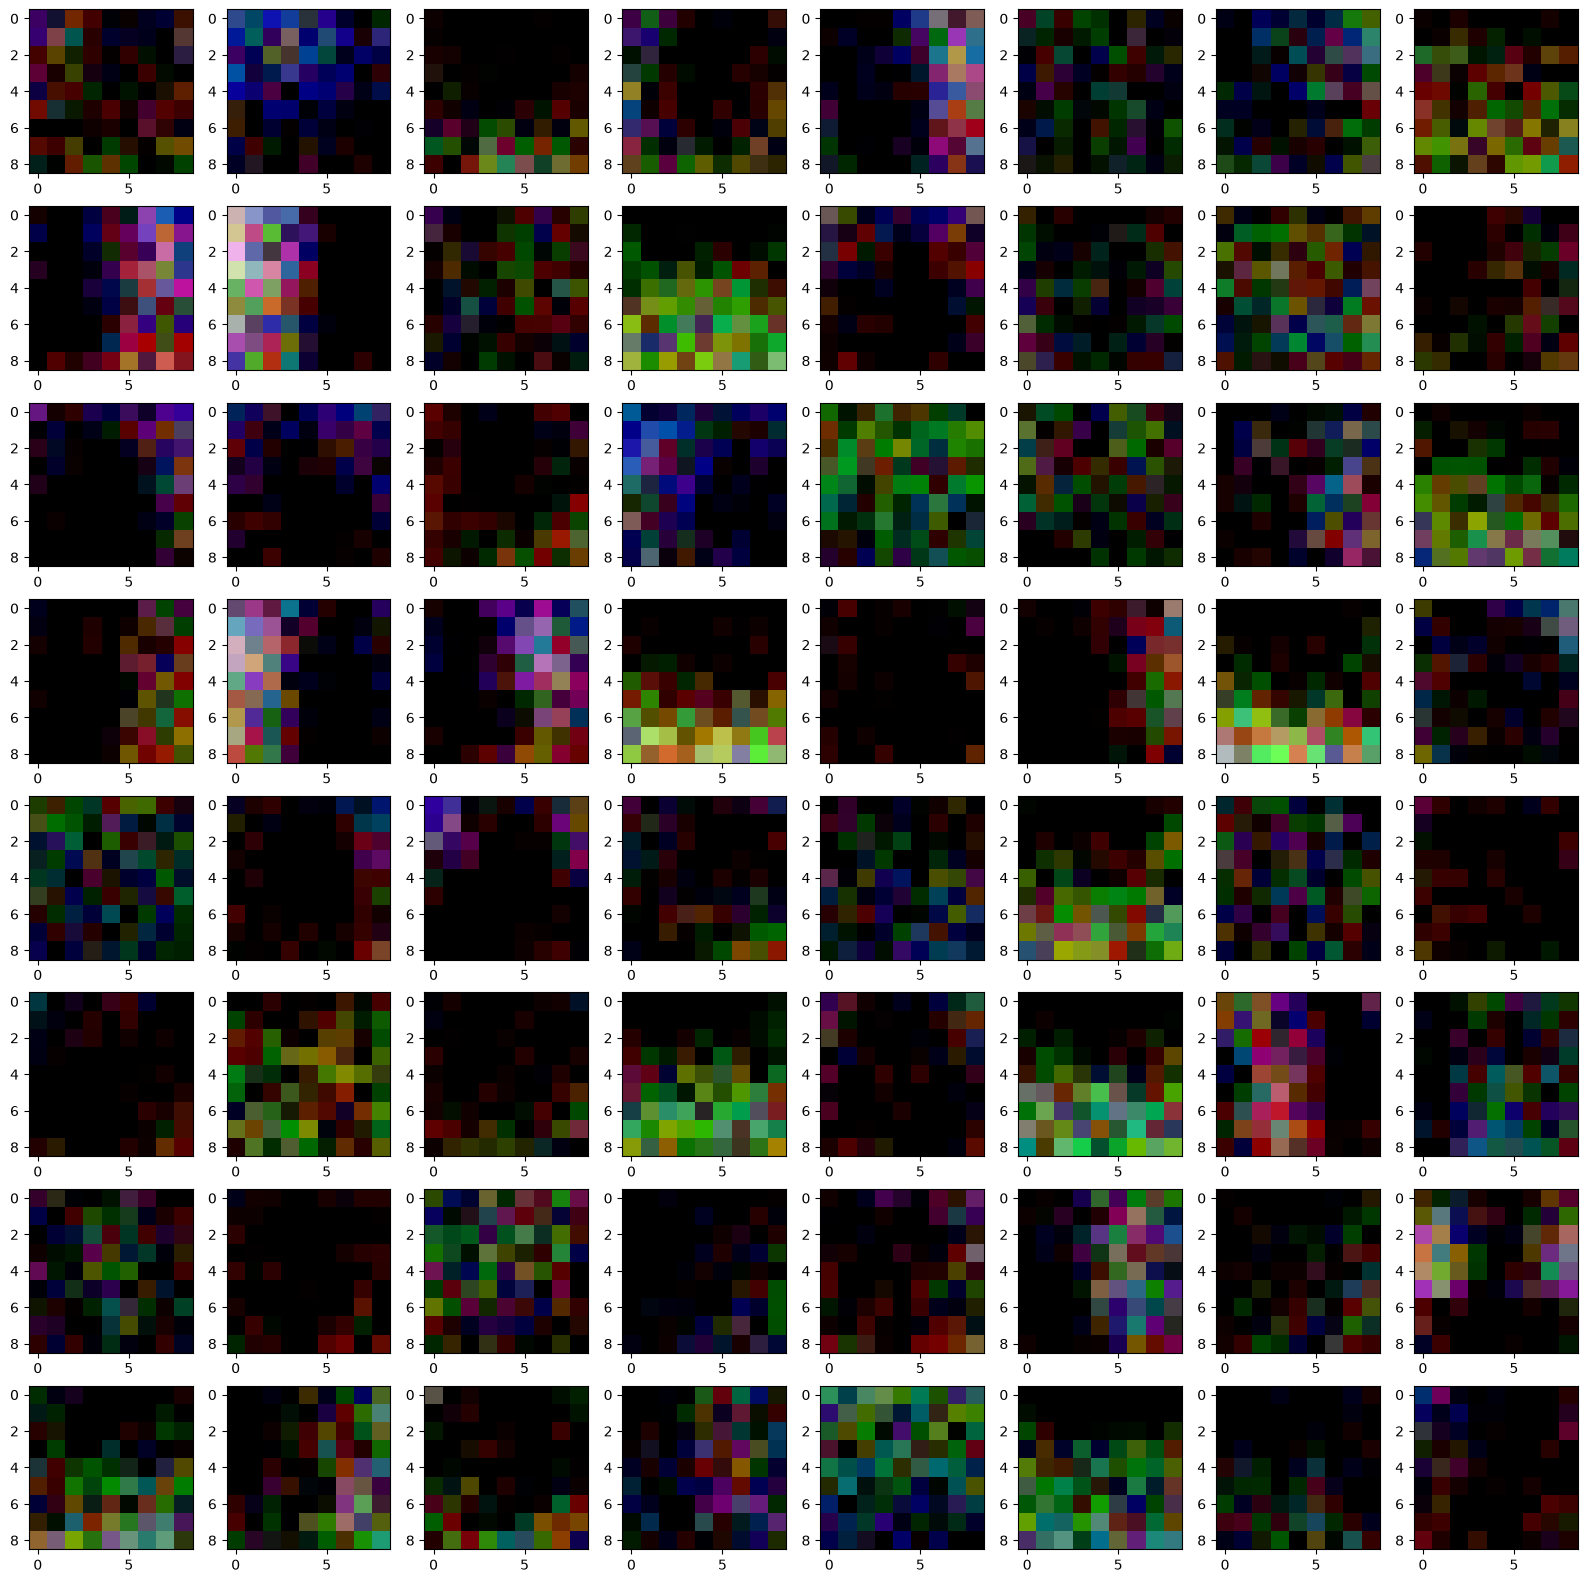

In [126]:
# Extracts the learned parameters from layer 2 (the first convolution layer)
filters, biases = model.layers[2].get_weights()
# kernel height, kernel width, input channels, num filters -> 64 filters, each 9x9 patch across 3 color channels
print(filters.shape)

fig, axes = plt.subplots(8, 8, figsize=(20, 20))

for i in range(8):
    for j in range(8):
        img = filters[:,:,:,i*8+j] * (1 / np.max(filters))
        axes[i][j].imshow(img)

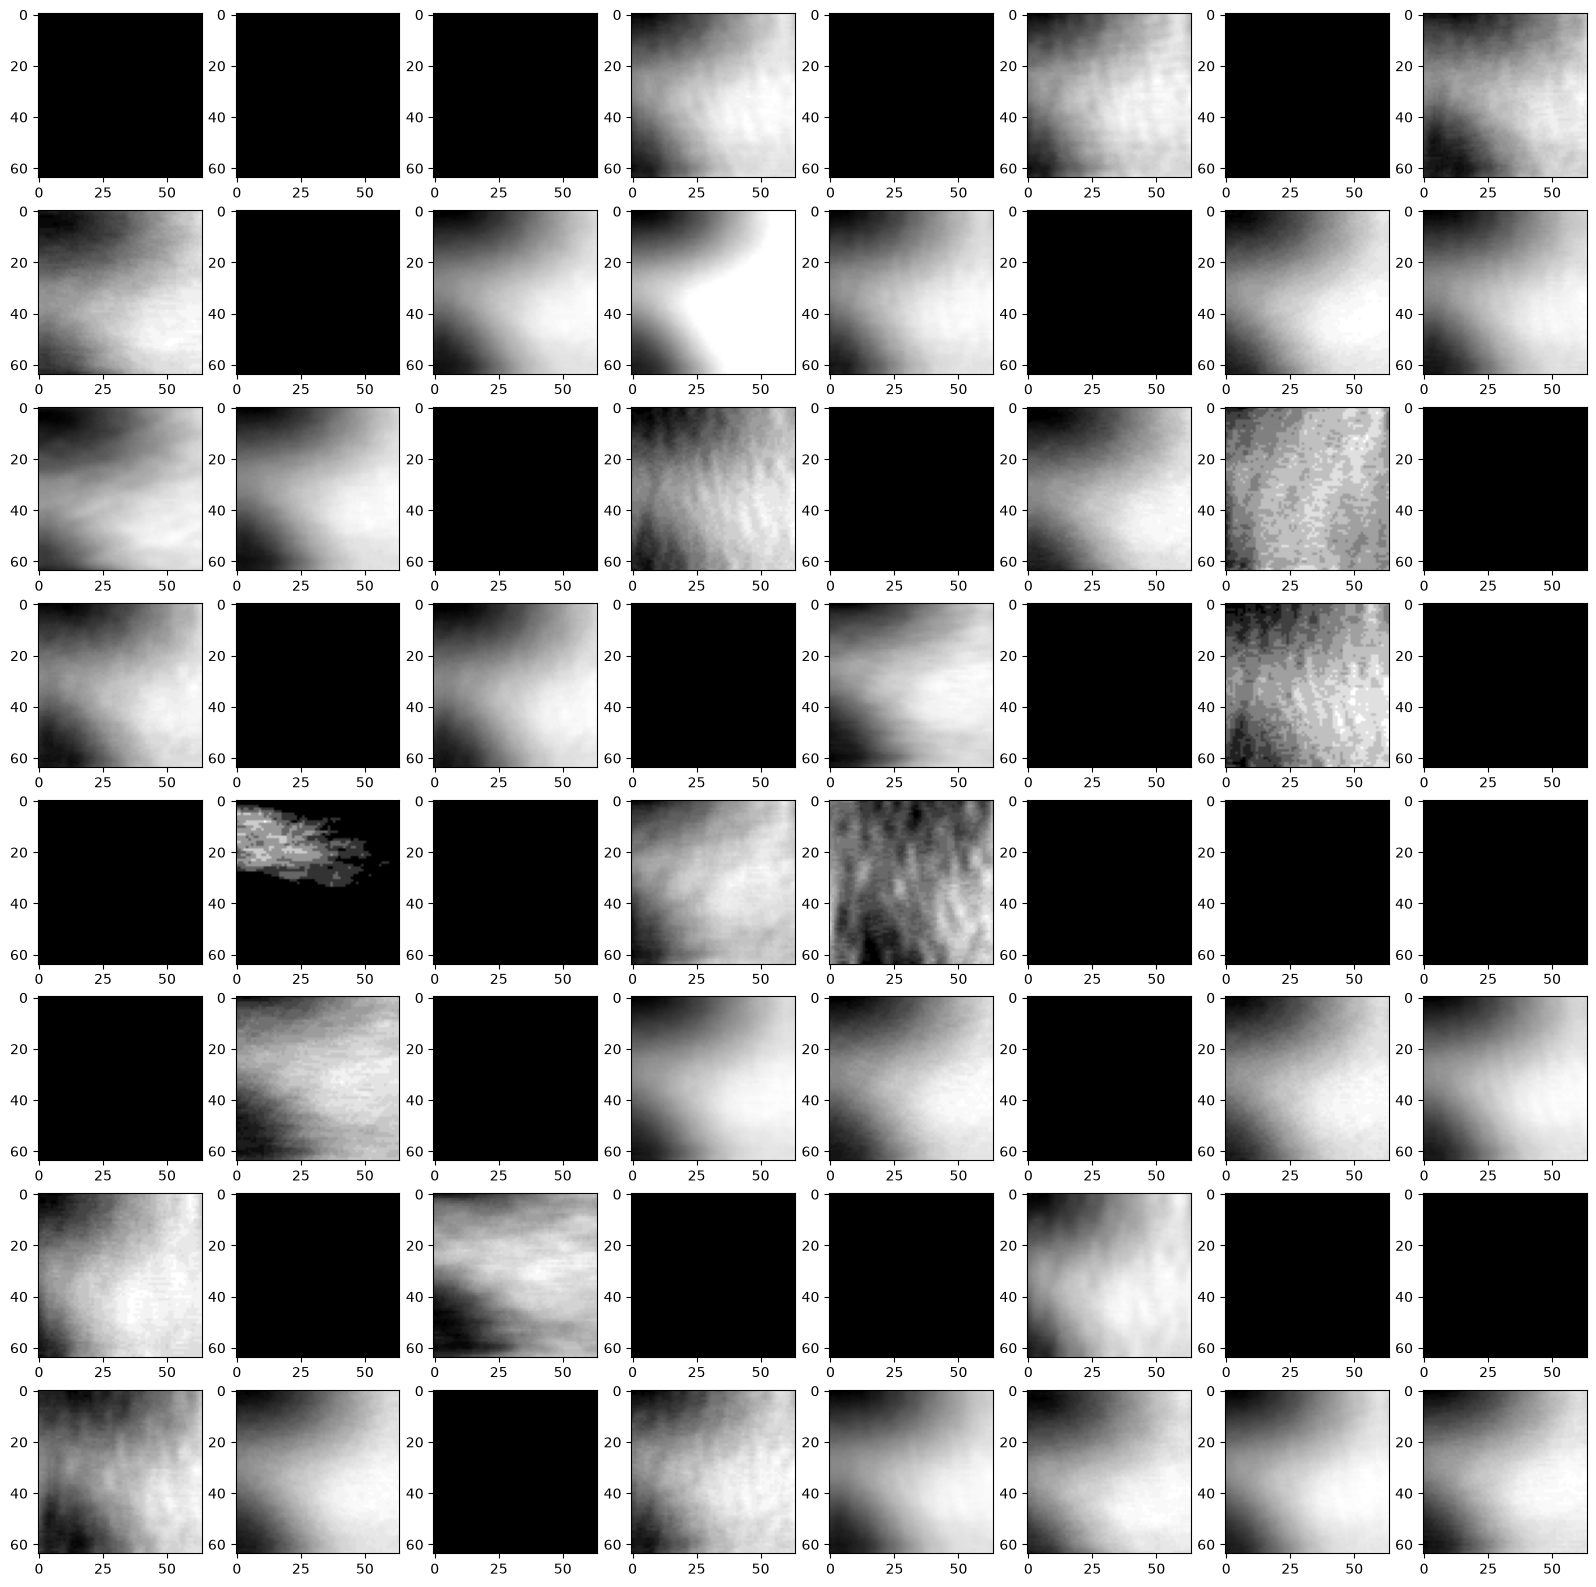

In [23]:
fig, axes = plt.subplots(8, 8, figsize=(20, 20))

for i in range(8):
    for j in range(8):
        #axes[i][j].imshow(filters[:,:,:,i*8+j] * 255, 'gray')
        
        # only channle 0 for demonstration purposes
        kernel = filters[:,:,0,i*8+j]

        #print(kernel.shape)

        gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
        filtered = cv2.filter2D(gray, -1, kernel)

        axes[i][j].imshow(filtered, 'gray')

## Transfer Learning

let's use a pre-trained model (VGG16) for our prediction

note that VGG16 needs three color channels

In [24]:
batch_size = 8
epochs = 50
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'leaky_relu'  # LeakyReLU
layer_count = 2
num_neurons = 256

# load a VGG16 model trained on the imagenet dataset
# include_top=False -> do not include the output layer
# input_tensor -> tells the model about the dimensions of our images (VGG16 needs three color channels)
# pooling -> which type of pooling to use between convolutions; max or avg seem to be the best
VGG = VGG16(weights='imagenet', include_top=False, input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)), pooling='max')

# we want to use the VGG's original weights -> make those layers untrainable
for layer in VGG.layers:
    layer.trainable = False

# build a new model and add the VGG layers
model_vgg = Sequential()
model_vgg.add(VGG)

# append dense layers at the end
for i in range(layer_count - 1):
    model_vgg.add(Dense(num_neurons, activation=activation))
model_vgg.add(Dropout(0.2))

model_vgg.add(Dense(num_neurons, activation=activation))

# classifier
model_vgg.add(Dense(num_classes, activation='softmax'))

model_vgg.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=0.0001)
stop_early = EarlyStopping(monitor='val_loss', patience=3)

In [127]:
history_vgg = model_vgg.fit(
    X_train,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, test_label),
    callbacks=[reduce_lr, stop_early]
)

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 523ms/step - accuracy: 0.9883 - loss: 0.0342 - val_accuracy: 0.9219 - val_loss: 0.2298 - learning_rate: 1.0000e-04
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 530ms/step - accuracy: 0.9883 - loss: 0.0360 - val_accuracy: 0.9297 - val_loss: 0.2213 - learning_rate: 1.0000e-04
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 574ms/step - accuracy: 0.9941 - loss: 0.0266 - val_accuracy: 0.9297 - val_loss: 0.2534 - learning_rate: 1.0000e-04
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 588ms/step - accuracy: 0.9980 - loss: 0.0231 - val_accuracy: 0.9375 - val_loss: 0.2345 - learning_rate: 1.0000e-04
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 526ms/step - accuracy: 0.9902 - loss: 0.0272 - val_accuracy: 0.9219 - val_loss: 0.2513 - learning_rate: 1.0000e-04


In [128]:
model_vgg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 512)            │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,308,363 (58.40 MB)

 Trainable params: 197,891 (773.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 395,784 (1.51 MB)

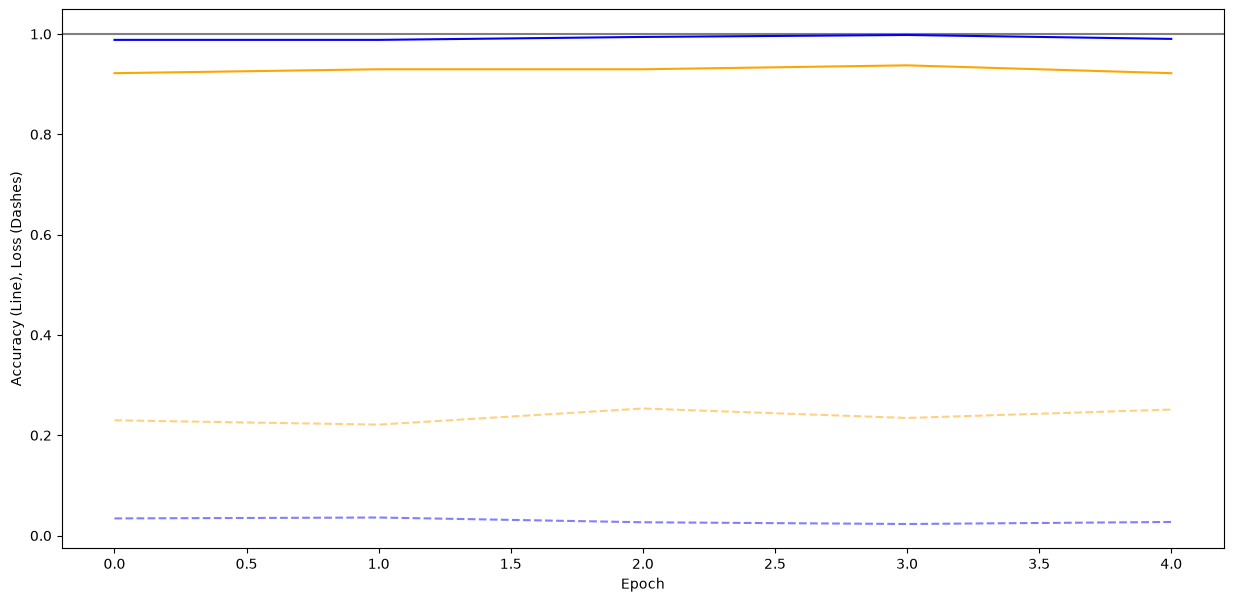

In [129]:
loss = history_vgg.history['loss']
val_loss = history_vgg.history['val_loss']
accuracy = history_vgg.history['accuracy']
val_accuracy = history_vgg.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (Line), Loss (Dashes)')

ax.axhline(1, color='gray')

plt.plot(accuracy, color='blue')
plt.plot(val_accuracy, color='orange')
plt.plot(loss, '--', color='blue', alpha=0.5)
plt.plot(val_loss, '--', color='orange', alpha=0.5)

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step
before [[4.28732857e-03 5.67212813e-02 9.38991427e-01]
 [9.99999940e-01 3.52295237e-09 4.58915572e-09]
 [9.99366045e-02 4.81434017e-01 4.18629348e-01]
 [5.13445644e-04 9.94536281e-01 4.95026261e-03]
 [1.11271031e-02 9.87866819e-01 1.00598985e-03]
 [9.99782085e-01 1.27949213e-04 8.99999868e-05]
 [9.99766827e-01 1.37153387e-04 9.60014950e-05]
 [9.97882545e-01 6.05244850e-06 2.11136322e-03]
 [9.99938428e-01 3.86690299e-05 2.29208053e-05]
 [1.75730602e-05 9.97597575e-01 2.38478160e-03]
 [1.85006410e-02 2.01460704e-01 7.80038595e-01]
 [9.99999702e-01 1.19013926e-07 1.09249356e-07]
 [2.07992244e-07 9.98681068e-01 1.31871598e-03]
 [1.53322471e-03 9.63335335e-01 3.51314172e-02]
 [7.42550671e-01 1.27008334e-01 1.30440950e-01]
 [3.45309973e-02 8.66590381e-01 9.88784805e-02]
 [9.29947941e-09 2.23629695e-06 9.99997675e-01]
 [9.98025143e-07 5.24576819e-07 9.99998391e-01]
 [9.99952734e-01 4.26921542e-05 4.54408200e-06]
 [5.29323643e-07 1.29797331e-06 9.99998152e-0

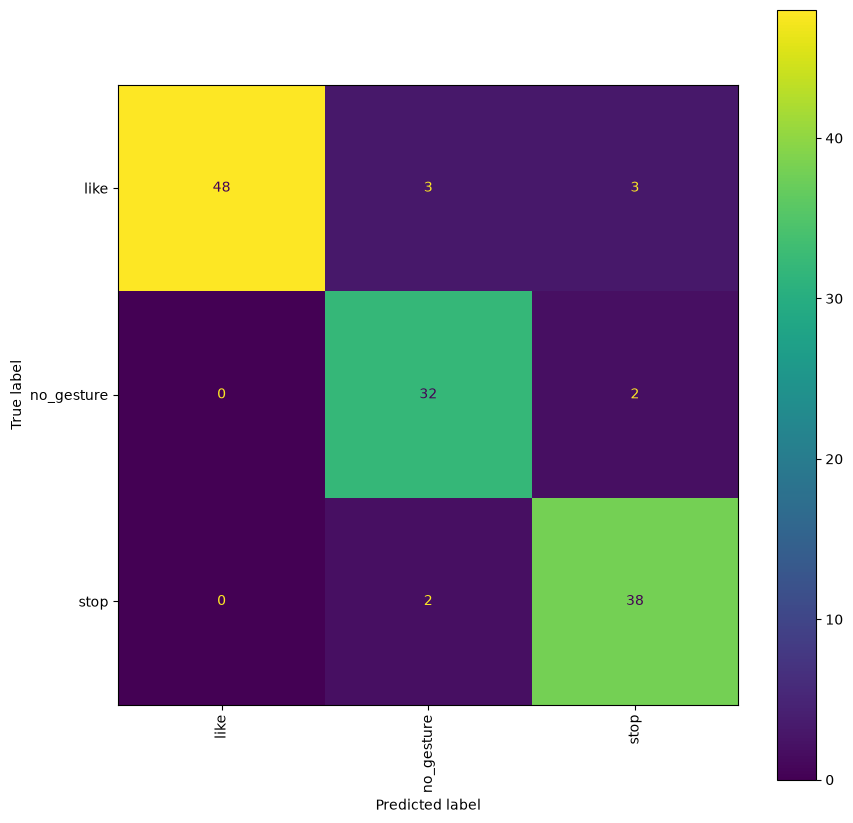

In [130]:
# let the model make predictions for our training data
y_predictions = model_vgg.predict(X_test)

# we get a 2D numpy array with probabilities for each category
print('before', y_predictions)

# to build a confusion matrix, we have to convert it to classifications
# this can be done by using the argmax() function to set the probability to 1 and the rest to 0
y_predictions = np.argmax(y_predictions, axis=1)

print('probabilities', y_predictions)

# create and plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_predictions)

fig = plt.figure(figsize=(10, 10))

ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())

plt.xticks(rotation=90, ha='center')
pass